In [ ]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
%matplotlib inline


### Step 1 - Data Loading

In [3]:
X_train_res = pd.read_csv("../data/processed_data/X_train.csv")
y_train_res = pd.read_csv("../data/processed_data/y_train.csv")
X_test = pd.read_csv("../data/processed_data/X_test.csv")
y_test = pd.read_csv("../data/processed_data/y_test.csv")

In [4]:
print(X_train_res.head())
print(y_train_res.head())
print(X_test.head())
print(y_test.head())

   RevolvingUtilizationOfUnsecuredLines  age  DebtRatio  MonthlyIncome  \
0                              0.000000   24   0.000000          820.0   
1                              0.230799   72  10.000000         5437.0   
2                              0.493403   46   0.618579         3250.0   
3                              1.000000   45  10.000000         5437.0   
4                              0.223070   29   0.184916         2200.0   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
0                                2                        0   
1                                7                        0   
2                                4                        0   
3                                4                        1   
4                                9                        0   

   NumberRealEstateLoansOrLines  NumberOfDependents  
0                             0                 0.0  
1                             0                 0.0  
2             

In [5]:
# Converting the 2D table into 1D for sklearn model
y_train_res = y_train_res.squeeze()
y_test = y_test.squeeze()

print(y_train_res.shape)


(223762,)


## Step 2 — Logistic Regression (Baseline Model)
Logistic Regression is the industry standard baseline for credit risk.
Simple, interpretable, and fast to train.
Any model we use must outperform this baseline.

In [6]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_res, y_train_res)

c:\Users\comp\OneDrive\Desktop\LABS\Credit Card loan ML project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [7]:
y_pred_lr = model.predict(X_test)
y_proba_lr = model.predict_proba(X_test)[:,1]


print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba_lr))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.97      0.76      0.85     27970
           1       0.17      0.72      0.28      1976

    accuracy                           0.75     29946
   macro avg       0.57      0.74      0.56     29946
weighted avg       0.92      0.75      0.81     29946

ROC-AUC Score: 0.8093410612729949



### Model Performance

| Metric | Class 0 (No Default) | Class 1 (Default) |
|--------|---------------------|-------------------|
| Precision | 0.97 | 0.17 |
| Recall | 0.76 | 0.72 |
| F1-Score | 0.85 | 0.28 |

**Overall Accuracy: 0.75**
**ROC-AUC Score: 0.809**

---

### Reading the Results

**What the model does well:**
- ROC-AUC of 0.809 shows decent overall discrimination ability
- Recall of 0.72 on defaulters means it catches 72% of real defaulters
- Very reliable at predicting non-defaulters (precision 0.97)

**What the model does poorly:**
- Precision of 0.17 on class 1 is very low
- For every 100 people flagged as defaulters only 17 actually default
- Too many false alarms — legitimate borrowers being flagged incorrectly

---

### Why Precision is Low
SMOTE creates synthetic defaulter rows during training.
Model becomes aggressive at predicting defaults — catches more real 
defaulters but also generates too many false alarms on real data.

---

### Baseline Set
This is the minimum bar every other model must beat.
Target: improve Class 1 Precision while maintaining Recall above 0.70
Next: Random Forest — expected to handle class boundaries better.

## Step 3 — Random Forest Classifier
Random Forest builds multiple decision trees and combines their predictions.
Expected to outperform Logistic Regression by capturing non-linear relationships
in the data that Logistic Regression cannot detect.

In [10]:
# Step 1 Create and training

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_res, y_train_res)

# Step 2 Predict
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:,1]
y_pred_rf = (y_proba_rf >= 0.3).astype(int)

# Step 3 Evaluate
print("=== RandomForestClassifier ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC-SCORE", roc_auc_score(y_test, y_proba_rf))

=== RandomForestClassifier ===
              precision    recall  f1-score   support

           0       0.97      0.78      0.86     27970
           1       0.17      0.64      0.26      1976

    accuracy                           0.77     29946
   macro avg       0.57      0.71      0.56     29946
weighted avg       0.92      0.77      0.82     29946

ROC-AUC-SCORE 0.779194280236633


## Step 4 — XGBoost Classifier
XGBoost is a gradient boosting algorithm that builds trees sequentially.
Each tree learns from the mistakes of the previous one.
Known to be the best performing model for tabular credit risk data.
Expected to outperform both Logistic Regression and Random Forest.

In [14]:
# Step 1 Create and training
xg_model = XGBClassifier(n_estimators=100, eval_metric = 'auc', n_jobs= -1)
xg_model.fit(X_train_res, y_train_res)

# Step 2 Predict
y_pred_xg = xg_model.predict(X_test)
y_proba_xg = xg_model.predict_proba(X_test)[:,1]
y_pred_xg_tuned = (y_proba_xg >= 0.3).astype(int)

# Step 3 Evaluate
print("=== XGBoost Classifier ===")
print(classification_report(y_test, y_pred_xg_tuned))
print("ROC-AUC-SCORE", roc_auc_score(y_test, y_proba_xg))

=== XGBoost Classifier ===
              precision    recall  f1-score   support

           0       0.97      0.77      0.86     27970
           1       0.17      0.65      0.26      1976

    accuracy                           0.76     29946
   macro avg       0.57      0.71      0.56     29946
weighted avg       0.92      0.76      0.82     29946

ROC-AUC-SCORE 0.7784485871936241


## Step 5 — Model Comparison
Comparing all three models to select the best one for deployment.
Primary metric: Recall on Class 1 (catching real defaulters)
Secondary metric: ROC-AUC (overall discrimination ability)

In [17]:
comparison = pd.DataFrame({
    'Model': ["LogisticRegression", "RandomForestClassifier", "XGBClassifier", "XGBClassifier(threshold 0.3)"],
    'Class 1 Precision': [0.17,0.22, 0.25, 0.17],
    'Class 1 recall': [0.72, 0.39, 0.43, 0.65],
    'Class 1 F1 score': [0.28, 0.30, 0.29, 0.26],
    'ROC-AUC': [0.809, 0.779, 0.778, 0.778],
    'Accuracy': [0.75, 0.88, 0.86, 0.76]
})

comparison

,Model,Class 1 Precision,Class 1 recall,Class 1 F1 score,ROC-AUC,Accuracy
0,LogisticRegression,0.17,0.72,0.28,0.809,0.75
1,RandomForestClassifier,0.22,0.39,0.30,0.779,0.88
2,XGBClassifier,0.25,0.43,0.29,0.778,0.86
3,XGBClassifier(threshold 0.3),0.17,0.65,0.26,0.778,0.76


### Model Comparison Visualization
Bar charts comparing key metrics across all models.

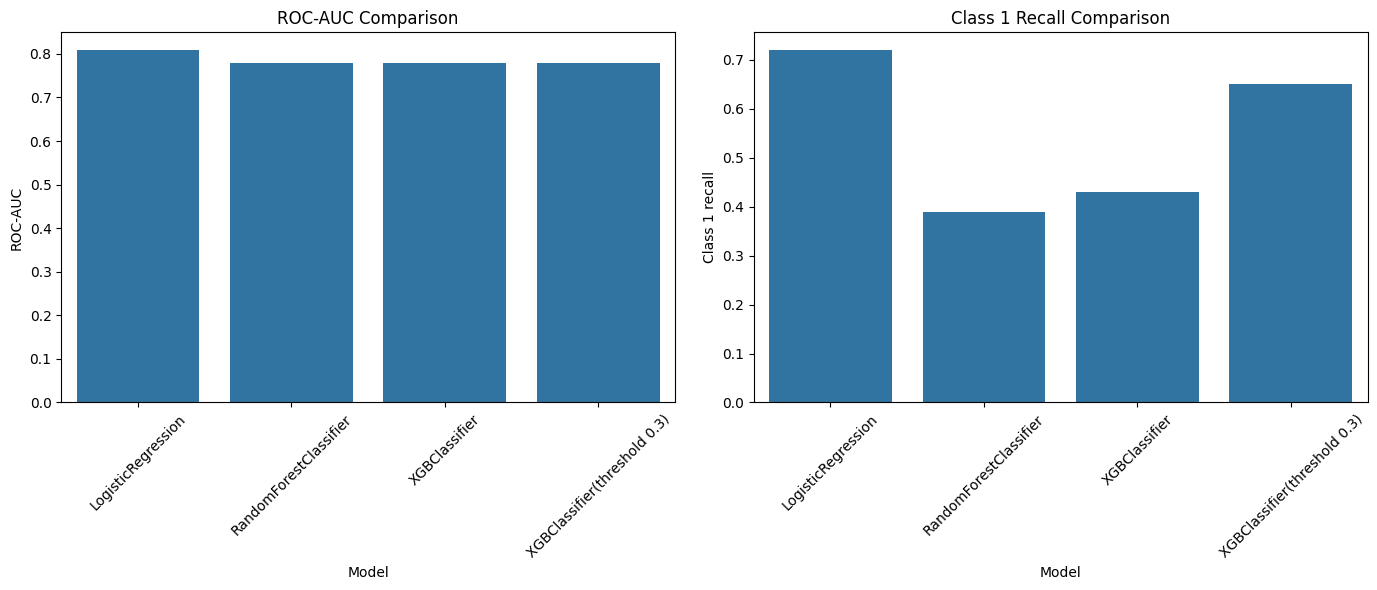

In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left chart - ROC AUC
sns.barplot(data=comparison, x='Model', y='ROC-AUC', ax=ax1)
ax1.set_title('ROC-AUC Comparison')
ax1.tick_params(axis='x', rotation=45)

# Right chart - Recall
sns.barplot(data=comparison, x='Model', y='Class 1 recall', ax=ax2)
ax2.set_title('Class 1 Recall Comparison')
ax2.tick_params(axis='x', rotation=45)




plt.tight_layout()
plt.show()

## Step 5 — Model Comparison and Final Selection

### Comparison Table

| Model | Precision (Class 1) | Recall (Class 1) | F1 (Class 1) | ROC-AUC | Accuracy |
|-------|---------------------|------------------|--------------|---------|----------|
| Logistic Regression | 0.17 | 0.72 | 0.28 | 0.809 | 0.75 |
| Random Forest | 0.25 | 0.39 | 0.30 | 0.779 | 0.88 |
| XGBoost (default) | 0.22 | 0.43 | 0.29 | 0.778 | 0.86 |
| XGBoost (threshold 0.3) | 0.17 | 0.65 | 0.26 | 0.778 | 0.76 |

---

### Why Logistic Regression Wins

**ROC-AUC:**
- Logistic Regression scores 0.809 — highest across all models
- Difference of 0.03 over XGBoost is meaningful in credit risk

**Recall on Defaulters:**
- Logistic Regression catches 72% of real defaulters
- Missing a defaulter costs the bank the entire loan amount
- Higher recall directly reduces financial loss

**Why LR outperforms tree models here:**
- Credit risk default probability has a mostly linear relationship with features
- Logistic Regression was specifically designed for binary classification
- Tree models like XGBoost and Random Forest shine on complex non-linear data
- This dataset does not have enough non-linear signal for them to exploit

---

### Final Model Selected — Logistic Regression

---

### Next Step
Save Logistic Regression as credit_risk_model.pkl
Then add SHAP explainability to understand why each prediction was made.

In [45]:
with open("../models/models.pkl", "wb") as f:
    pickle.dump(model, f)

print("Saved Model Successfully")

Saved Model Successfully


In [46]:
with open("../models/models.pkl", "rb") as f:
    loaded_model = pickle.load(f)

print(loaded_model)

LogisticRegression(max_iter=1000)


## Phase 4 — SHAP Explainability
Using SHAP to explain model predictions.
Lenders are legally required to explain loan rejections.
SHAP makes this model production-grade and interview-ready.

c:\Users\comp\OneDrive\Desktop\LABS\Credit Card loan ML project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


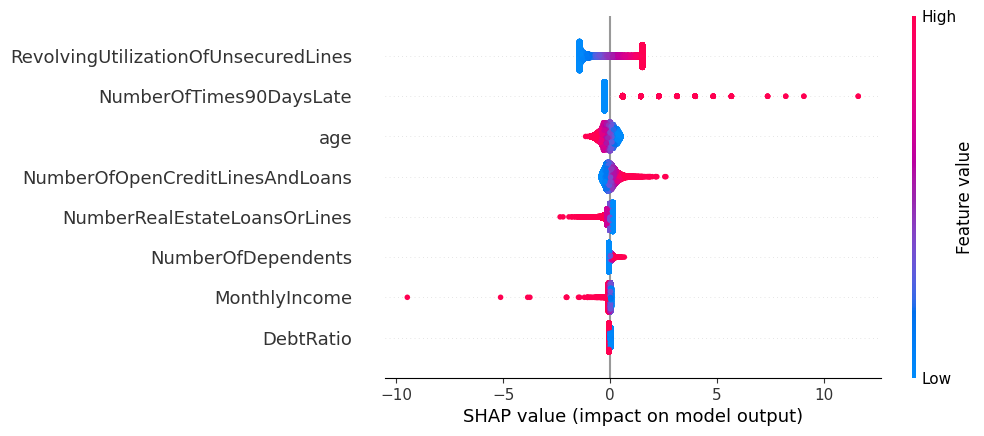

In [47]:
import shap

# 1. initialize the explainer
explainer = shap.Explainer(model,X_train_res)

# 2. Calculate the shap values
shap_values = explainer(X_test)

# 3. Visualize the explaination 
shap.plots.beeswarm(shap_values)

### SHAP Summary Plot Findings

**Most Important Features:**
1. RevolvingUtilizationOfUnsecuredLines — strongest predictor
   High credit utilization strongly pushes toward default

2. NumberOfTimes90DaysLate — second strongest
   More late payments = higher default risk

3. Age — third
   Younger borrowers carry slightly higher risk

4. MonthlyIncome — fourth
   Lower income increases default probability

5. DebtRatio — least important
   Minimal impact after capping at 10

**Key Insight:**
Credit behavior (utilization and late payments) matters more
than financial capacity (income and debt ratio) in predicting default.

### SHAP Bar Plot — Feature Importance Ranking
Shows the average impact of each feature across all predictions.
Higher bar = feature has more influence on model decisions overall.

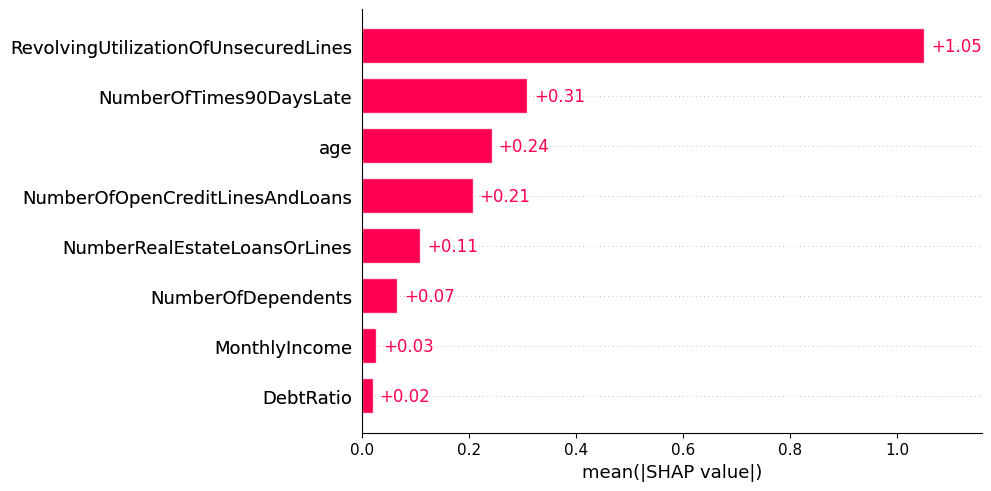

In [48]:
# 1. initialize the explainer
explainer = shap.Explainer(model,X_train_res)

# 2. Calculate the shap values
shap_values = explainer(X_test)

# 3. Visualize the explaination 
shap.plots.bar(shap_values)

### SHAP Waterfall Plot — Single Prediction Explanation
Shows exactly why the model predicted default or no default
for one specific borrower. This is what a loan officer would
show a customer when explaining a rejection decision.

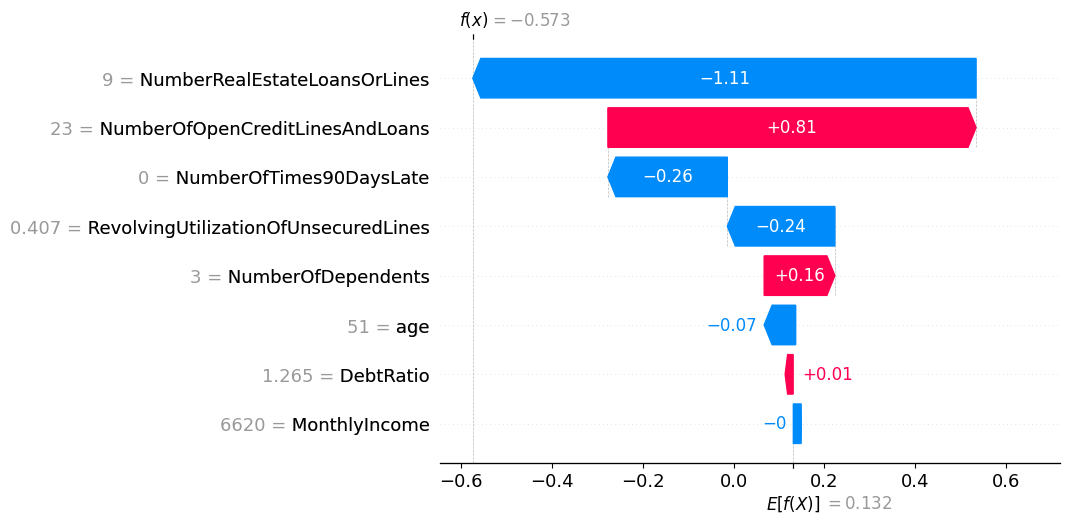

In [52]:
# 1. initialize the explainer
explainer = shap.Explainer(model,X_train_res)

# 2. Calculate the shap values
shap_values = explainer(X_test)

# 3. Visualize the explaination 
shap.plots.waterfall(shap_values[0])

### Waterfall Plot — Person 0 Analysis

Starting default probability → 13.2% (base rate)

Factors reducing risk:
- 9 real estate loans → strong asset ownership signal (-1.11)
- Zero 90-day late payments → excellent payment history (-0.26)
- Moderate credit utilization at 40% (-0.24)
- Mature age of 51 (-0.07)

Factors increasing risk:
- 23 open credit lines → too many accounts (+0.81)
- 3 dependents → higher financial obligations (+0.16)

Final prediction → very low default probability
Model correctly identifies this as a low risk borrower.